P.K.M.P. KUMARA
230353N 

1. Implement the intensity transformation

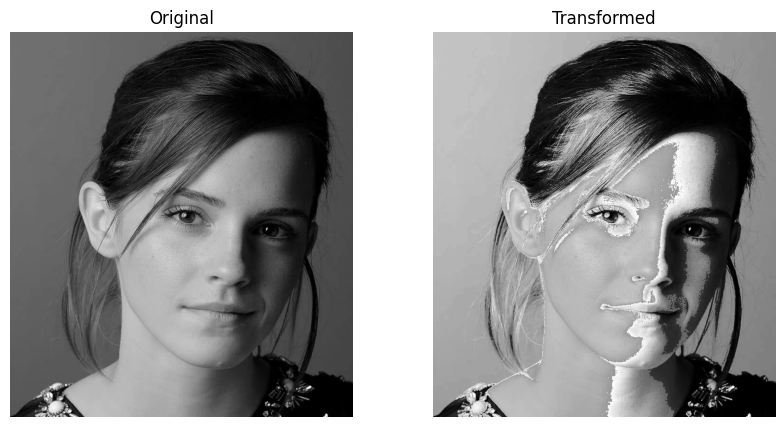

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def intensity_transform(im, breakpoints):   #Define Intensity Transform Func.
    im = np.asarray(im, dtype=np.float64)
    output = np.zeros_like(im)
    filled = np.zeros_like(im, dtype=bool)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, skip

        mask = (im >= x0) & (im <= x1) & (~filled)
        output[mask] = y0 + (y1 - y0) * (im[mask] - x0) / (x1 - x0)
        filled |= mask

    return np.clip(output, 0, 255).astype(np.uint8)

img = Image.open('emma_01.jpg').convert('L')  #image in grayscale
img_arr = np.array(img)

breakpoints = [                    #Breakpoints
    [0,   0],
    [50,  50],
    [50,  100],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed = intensity_transform(img_arr, breakpoints) # Apply transform
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  #show original and transformed pics
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

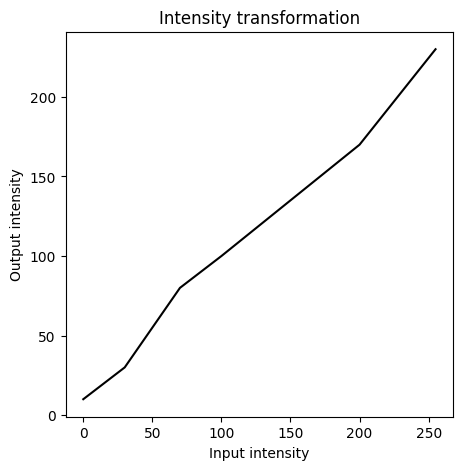

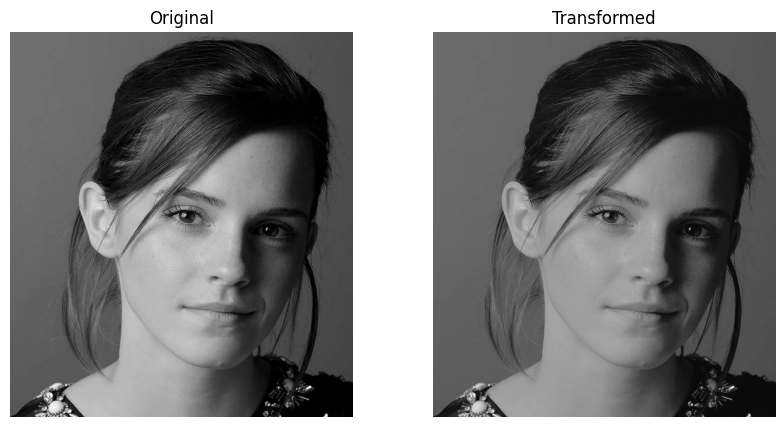

In [2]:
breakpoints = [      #my break points
    [0,   10],
    [30, 30],            #keep hair looking pleasant black
    [70, 80],
    [100, 100],
    [200, 170],          #left side of the face more bright. I reduced it.
    [255, 230],
]

transformed = intensity_transform(img_arr, breakpoints)

bp = np.array(breakpoints)         #plot transformation graph
plt.figure(figsize=(5, 5))
plt.plot(bp[:, 0], bp[:, 1], color='black')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

2. White matter , Gray matter of the brain

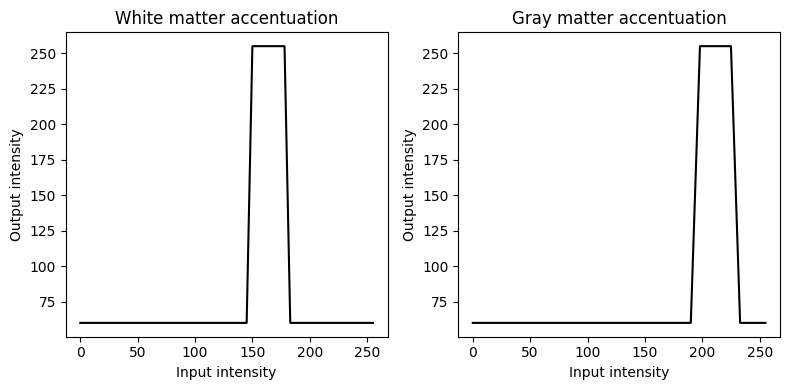

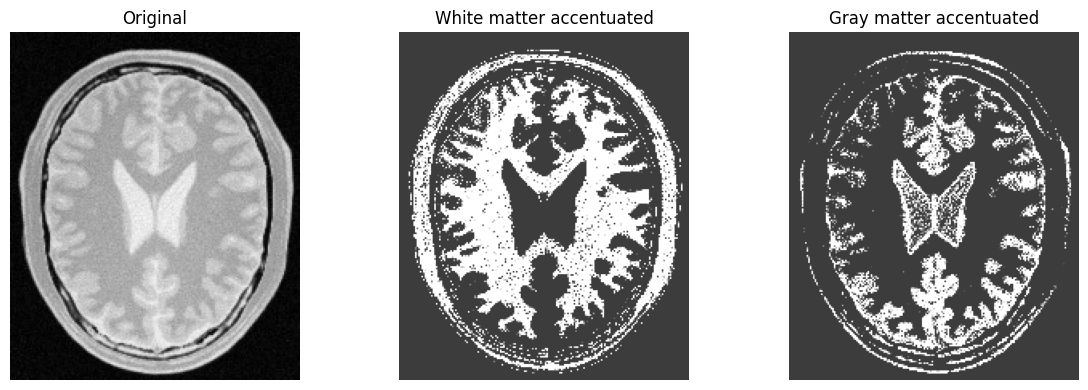

In [3]:
wm_breakpoints = [
    [0,   60],
    [145, 60],
    [150, 255],
    [178, 255],
    [183, 60],
    [255, 60],
]

gm_breakpoints = [
    [0,   60],
    [190, 60],
    [198, 255],
    [225, 255],
    [233, 60],
    [255, 60],
]
img = Image.open("brain_2.jpg").convert("L")
arr = np.array(img)
wm_img = intensity_transform(arr, wm_breakpoints)
gm_img = intensity_transform(arr, gm_breakpoints)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (bp, name) in zip(axes, [(wm_breakpoints, 'White matter'), (gm_breakpoints, 'Gray matter')]):
    bp_arr = np.array(bp)
    ax.plot(bp_arr[:, 0], bp_arr[:, 1], color='black')
    ax.set_xlabel('Input intensity')
    ax.set_ylabel('Output intensity')
    ax.set_title(f'{name} accentuation')
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(arr, cmap='gray', vmin=0, vmax=255); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(wm_img, cmap='gray', vmin=0, vmax=255); axes[1].set_title('White matter accentuated'); axes[1].axis('off')
axes[2].imshow(gm_img, cmap='gray', vmin=0, vmax=255); axes[2].set_title('Gray matter accentuated'); axes[2].axis('off')
plt.tight_layout()
plt.show()

3. Gamma correction and histogram

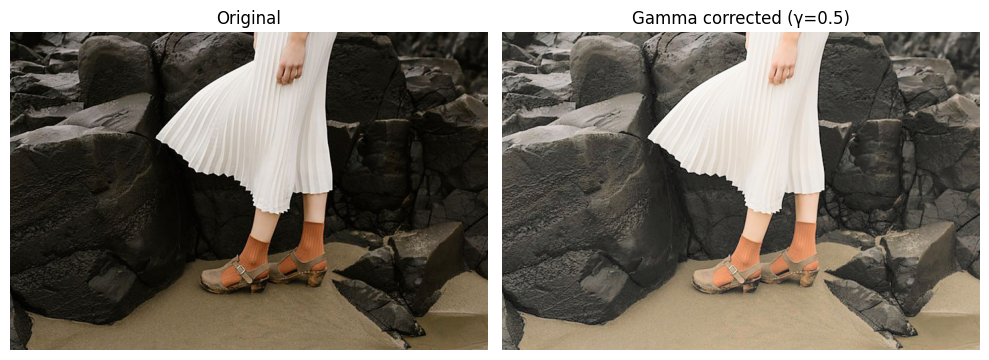

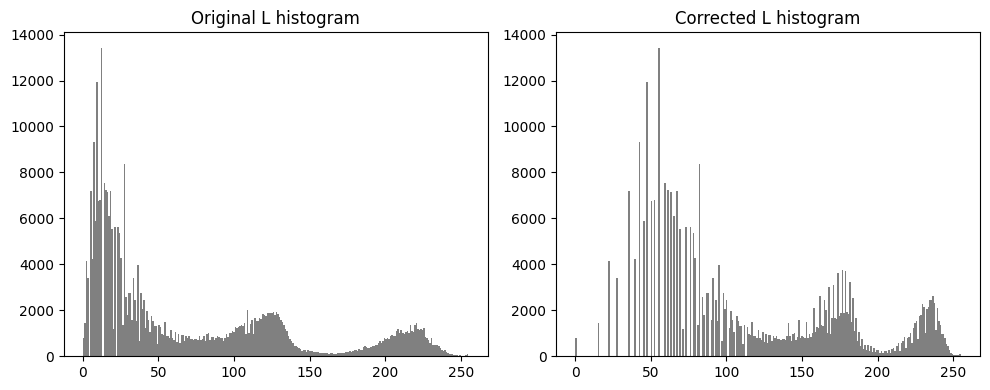

In [4]:
import cv2
img = cv2.imread('stonewhite_3.jpg')

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB) #convert to L*a*b* and channel split
L, a, b = cv2.split(lab)

gamma = 0.5   # gamma < 1 , to L 
L_norm = L.astype(np.float64) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = L_gamma.astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])   #corrected L merge back
img_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (γ={gamma})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Corrected L histogram')
plt.tight_layout()
plt.show()

4. Intensity Transform to saturation plane

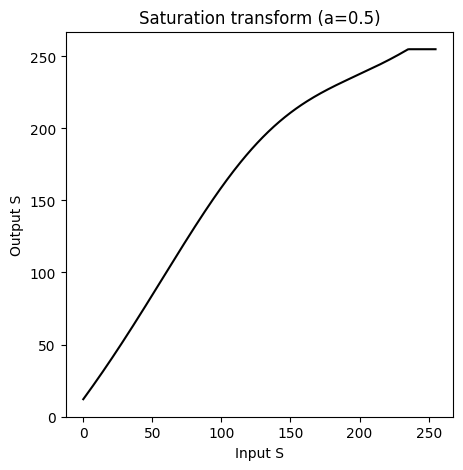

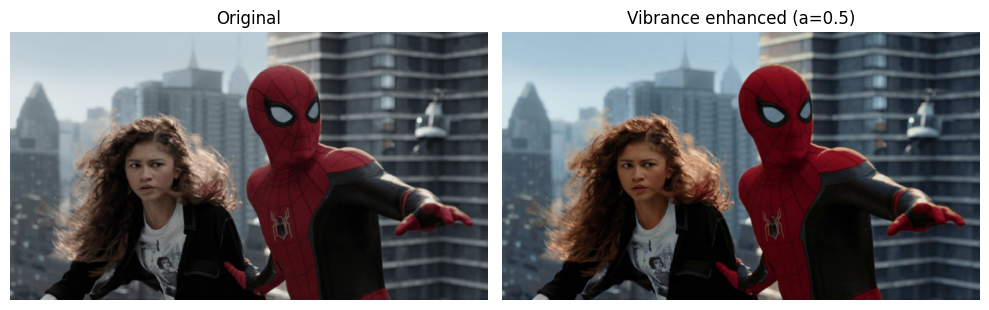

In [5]:
img = cv2.imread('spiderman_4.jpeg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)     #split to H, S, V planes

def vibrance_transform(x, a, sigma=70):   #define the vibrance transform func.
    x = x.astype(np.float64)
    boosted = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255)

a = 0.5
S_new = vibrance_transform(S, a).astype(np.uint8) #apply transform to S plane

hsv_new = cv2.merge([H, S_new, V])   #recombine H, new S and V
img_new = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)   #back to BGR

x = np.arange(256)
curve = vibrance_transform(x, a)
plt.figure(figsize=(5, 5))
plt.plot(x, curve, color='black')
plt.xlabel('Input S')
plt.ylabel('Output S')
plt.title(f'Saturation transform (a={a})')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a={a})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

5. Histogram Equalization

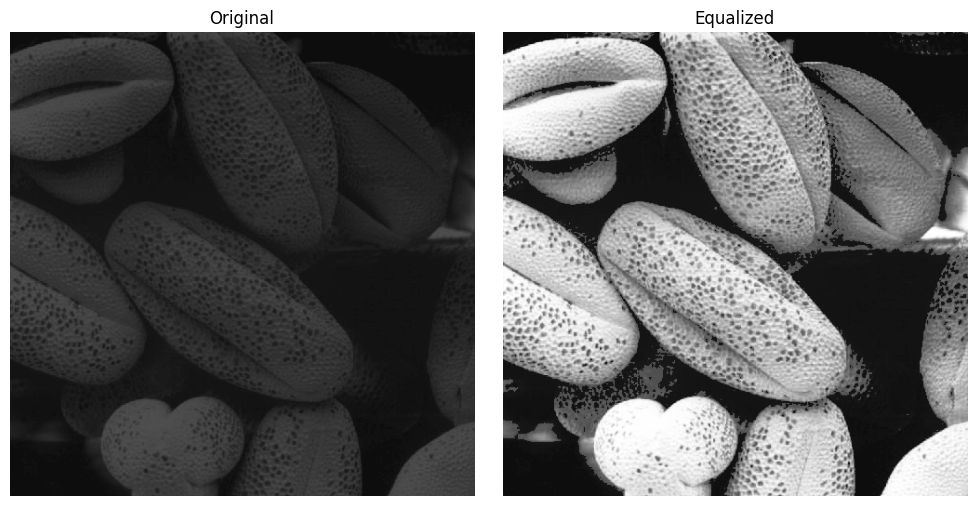

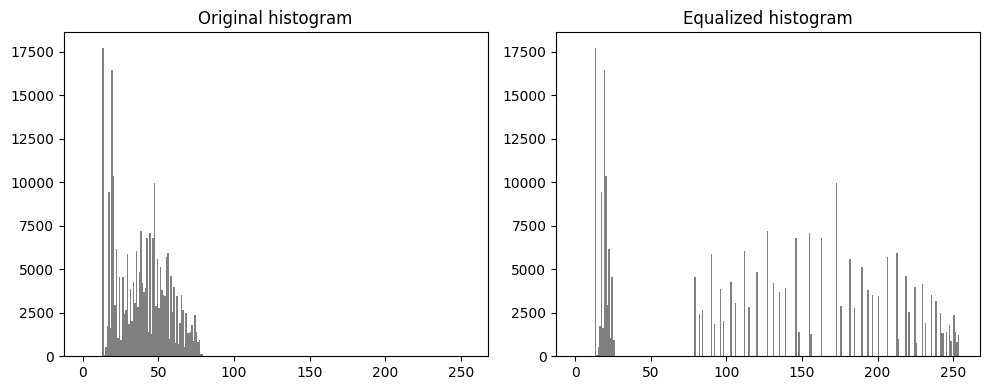

In [6]:
def my_hist_equalize(img):
    img = np.asarray(img)
    hist = np.bincount(img.ravel(), minlength=256) #histogram
    cdf = np.cumsum(hist) #CDF
    cdf_normalized = (            #normalize CDF
        (cdf - cdf.min()) /
        (cdf.max() - cdf.min()) * 255
    )
    lut = cdf_normalized.astype(np.uint8)

    dark_threshold = 26  #keep very dark pixels unchange.(common histogram at threshhold=0)
    lut[:dark_threshold] = np.arange(dark_threshold)

    equalized = lut[img]     #LUT

    return equalized

img = np.array(Image.open('shells_5.tif'))
eq = my_hist_equalize(img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(eq, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Equalized')
axes[1].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(img.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original histogram')
axes[1].hist(eq.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Equalized histogram')
plt.tight_layout()
plt.show()

6. Histogram equalization only to the foreground

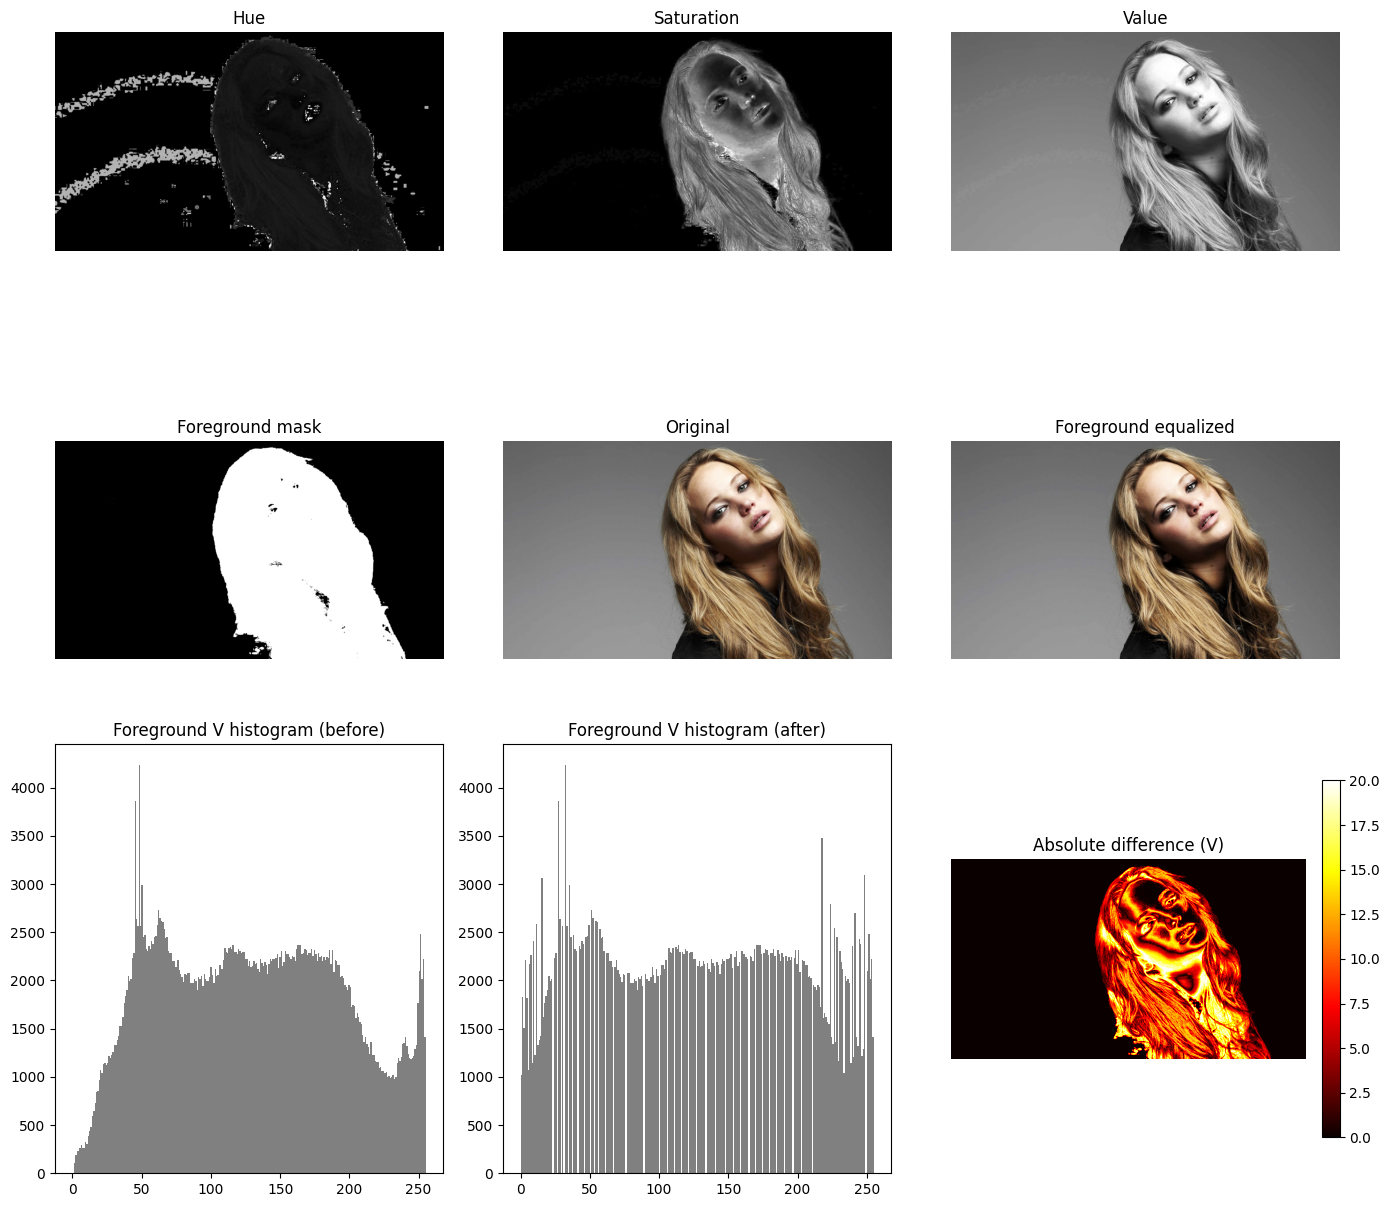

In [12]:
img = cv2.imread('Jennifer_6.jpeg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)    #convert to HSV
H, S, V = cv2.split(hsv)

_, mask = cv2.threshold(S, 15, 255, cv2.THRESH_BINARY) #background nearly gray. choose S plane. 
fg_V = cv2.bitwise_and(V, V, mask=mask)
hist_fg = cv2.calcHist([V], [0], mask, [256], [0, 256]).flatten()
n_fg = int(mask.sum() / 255)  

cdf = np.cumsum(hist_fg)
cdf_min = cdf[cdf > 0].min()
lut = np.round((cdf - cdf_min) / (n_fg - cdf_min) * 255).clip(0, 255).astype(np.uint8)
equalized_fg_V = cv2.bitwise_and(lut[V], lut[V], mask=mask)

mask_inv = cv2.bitwise_not(mask)
background_V = cv2.bitwise_and(V, V, mask=mask_inv)
new_V = cv2.add(background_V, equalized_fg_V)

hsv_result = cv2.merge([H, S, new_V])
result = cv2.cvtColor(hsv_result, cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
axes[0,0].imshow(H, cmap='gray'); axes[0,0].set_title('Hue'); axes[0,0].axis('off')
axes[0,1].imshow(S, cmap='gray'); axes[0,1].set_title('Saturation'); axes[0,1].axis('off')
axes[0,2].imshow(V, cmap='gray'); axes[0,2].set_title('Value'); axes[0,2].axis('off')
axes[1,0].imshow(mask, cmap='gray'); axes[1,0].set_title('Foreground mask'); axes[1,0].axis('off')
axes[1,1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[1,1].set_title('Original'); axes[1,1].axis('off')
axes[1,2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); axes[1,2].set_title('Foreground equalized'); axes[1,2].axis('off')

# Row 3: histograms (foreground only, before/after) and the difference image
axes[2,0].hist(V[mask > 0].ravel(), bins=256, range=(0, 255), color='gray')
axes[2,0].set_title('Foreground V histogram (before)')

axes[2,1].hist(new_V[mask > 0].ravel(), bins=256, range=(0, 255), color='gray')
axes[2,1].set_title('Foreground V histogram (after)')

diff = cv2.absdiff(V, new_V)
im = axes[2,2].imshow(diff, cmap='hot')
axes[2,2].set_title('Absolute difference (V)')
axes[2,2].axis('off')
fig.colorbar(im, ax=axes[2,2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

7. Sobel Filter